In [20]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

In [22]:
class StoryState(TypedDict):
    title: str
    content: str
    summary: str

In [23]:
def create_content(state: StoryState) -> StoryState:
    # Create the content for the story
    title = state["title"]
    prompt_template = ChatPromptTemplate.from_template("Write a 100-word story about {title}.")
    chain = prompt_template | llm
    response = chain.invoke({"title": title})
    return {"content": response.content}

def create_summary(state: StoryState) -> StoryState:
    # Create a summary of the story
    content = state["content"]
    prompt_template = ChatPromptTemplate.from_template("Summarize the following story in one sentence: {content}")
    chain = prompt_template | llm
    response = chain.invoke({"content": content})
    return {"summary": response.content}

In [24]:
# Create the state graph
graph = StateGraph(StoryState)

# Add nodes
graph.add_node("create_content", create_content)
graph.add_node("create_summary", create_summary)

# Add edges
graph.add_edge(START, "create_content")
graph.add_edge("create_content", "create_summary")
graph.add_edge("create_summary", END)

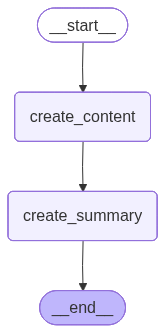

In [25]:
app = graph.compile()
app

In [26]:
result = app.invoke({"title": "The Lost Key"})
print(result['content'])
print("\nSummary:")
print(result['summary'])

In the heart of the ancient forest, young Elara stumbled upon a peculiar key, half-buried beneath a gnarled oak. Its intricate design shimmered with an otherworldly glow, whispering secrets of forgotten realms. Driven by curiosity, she embarked on a quest to uncover its purpose. Guided by cryptic symbols and tales of old, Elara journeyed through mist-laden valleys and over moonlit peaks. Each step brought her closer to the truth, unraveling the legend of a hidden door that bridged worlds. As dawn broke, she found it—a portal shimmering with possibilities. With a deep breath, Elara turned the key, unlocking destiny.

Summary:
Young Elara discovered a mysterious key in an ancient forest and embarked on a quest through mystical landscapes to unlock a portal bridging worlds.
